In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutProductMultipleAssets, Put

In [2]:
n_assets = 3

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5, 0.6])
correlation_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

sigma = build_covariance_matrix(stds, correlation_matrix)

K = 8.0
T = 1.0
S_min = 0.0
S_max = 3 * S0

market_params = MarketParams(n_assets=3, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = n_assets + 1
hidden_sizes = [32, 64, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put_product = PutProductMultipleAssets()
trainer_product = GeneralTrainer(model_config, market_params, put_product, 67)
trainer_product.train(num_samples=1000, max_iterations=10000, tol=1e-4)

Iteration 0, Loss: 232.45443725585938
Iteration 100, Loss: 74.85211944580078
Iteration 200, Loss: 23.131296157836914
Iteration 300, Loss: 14.387031555175781
Iteration 400, Loss: 10.49610710144043
Iteration 500, Loss: 7.817903995513916
Iteration 600, Loss: 7.464170455932617
Iteration 700, Loss: 5.945617198944092
Iteration 800, Loss: 6.385832786560059
Iteration 900, Loss: 5.2967376708984375
Iteration 1000, Loss: 4.713072299957275
Iteration 1100, Loss: 4.6822509765625
Iteration 1200, Loss: 4.088864803314209
Iteration 1300, Loss: 4.003247261047363
Iteration 1400, Loss: 4.488927841186523
Iteration 1500, Loss: 3.8272385597229004
Iteration 1600, Loss: 3.5889880657196045
Iteration 1700, Loss: 3.3900599479675293
Iteration 1800, Loss: 2.689237356185913
Iteration 1900, Loss: 3.791408061981201
Iteration 2000, Loss: 3.125396251678467
Iteration 2100, Loss: 2.927863836288452
Iteration 2200, Loss: 2.5297133922576904
Iteration 2300, Loss: 3.0840697288513184
Iteration 2400, Loss: 3.421955108642578
Itera

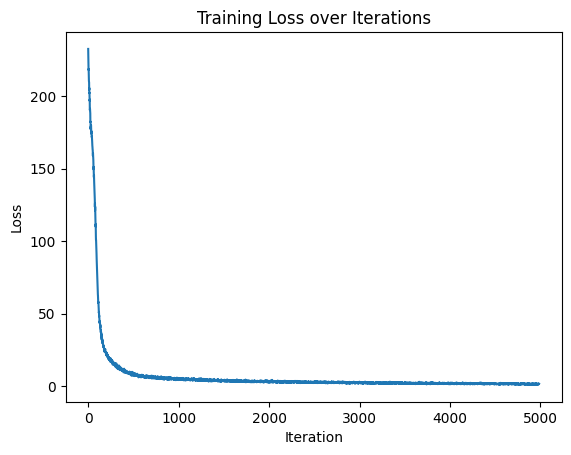

In [5]:
trainer_product.plot_losses()

In [6]:
trainer_product.predict(1, 2, 2, 2).item()

0.26324430108070374

## Compare with 1D case

Iteration 0, Loss: 89.95785522460938
Iteration 100, Loss: 9.585519790649414
Iteration 200, Loss: 0.2275473028421402
Converged at iteration 295


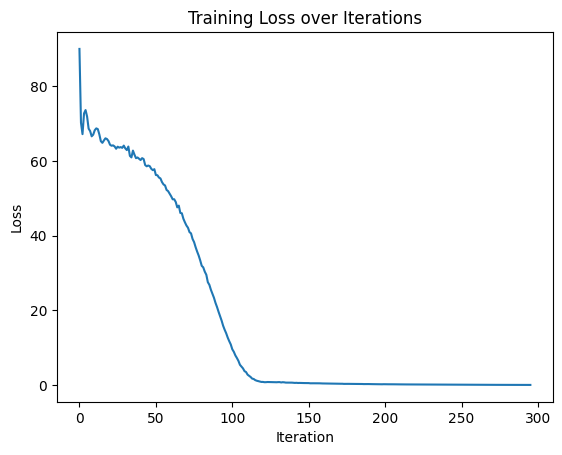

In [7]:
r_prime = n_assets * r + np.sum(np.tril(sigma, k=-1))
sigma_prime = np.sqrt(np.sum(sigma))

market_params_1d = MarketParams(
    n_assets=1,
    S0=S0**n_assets,
    r=r_prime,
    sigma=sigma_prime,
    K=K,
    T=T,
    S_min=S_min**n_assets,
    S_max=S_max**n_assets
)
put_1d = Put()
model_config_1d = ModelConfig(
    input_size=2,
    hidden_sizes=[32, 64, 32],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=0.001
)
trainer_1d = GeneralTrainer(model_config_1d, market_params_1d, put_1d, 67)
trainer_1d.train(num_samples=1000, max_iterations=10000, tol=1e-4)
trainer_1d.plot_losses()

In [8]:
as1 = np.array([2, 2, 2])
print(trainer_product.predict(1, *as1).item())
print(trainer_1d.predict(1, np.prod(as1)).item())

0.26324430108070374
0.3271624445915222


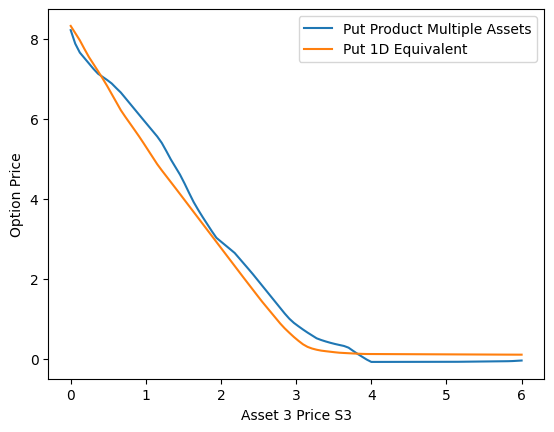

In [9]:
b = 100

t = np.full(b, 1.0)
s1 = np.full(b, 3.2)
s2 = np.full(b, 0.8)
s3 = np.linspace(0.0, 6.0, b)


putproduct = trainer_product.predict(t, s1, s2, s3).detach().numpy()
put1d = trainer_1d.predict(t, s1 * s2 * s3).detach().numpy()
plt.plot(s3, putproduct, label='Put Product Multiple Assets')
plt.plot(s3, put1d, label='Put 1D Equivalent')
plt.xlabel('Asset 3 Price S3')
plt.ylabel('Option Price')
plt.legend()
plt.show()